In [41]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from category_encoders import HashingEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import VarianceThreshold, SelectKBest,SelectFpr, chi2, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("GEDEvent_v25_1.csv")

/tmp/ipykernel_40667/3297232117.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("GEDEvent_v25_1.csv")


# Problema de ML

Definimos a la variable target `Severidad` que es una variable categorica ordinal computada en base a la cantidad de fallecidos. Se propone hacer uso de la escala del paper [A Universal Severity Classication for Natural Disasters](https://scispace.com/pdf/a-universal-severity-classification-for-natural-disasters-csvzrnqtj1.pdf)

In [3]:
bins = [
    -np.inf,       # Límite inferior
    1,             # [ < 1 ] -> UDSCS 0
    10,            # [ 1 a < 10 ] -> UDSCS 1
    100,           # [ 10 a < 100 ] -> UDSCS 2
    1000,          # [ 100 a < 1,000 ] -> UDSCS 3
    10000,         # [ 1,000 a < 10,000 ] -> UDSCS 4
    100000,        # [ 10,000 a < 100,000 ] -> UDSCS 5
    1000000,       # [ 100,000 a < 1,000,000 ] -> UDSCS 6
    10000000,      # [ 1,000,000 a < 10,000,000 ] -> UDSCS 7
    100000000,     # [ 10,000,000 a < 100,000,000 ] -> UDSCS 8
    1000000000,    # [ 100,000,000 a < 1,000,000,000 ] -> UDSCS 9
    np.inf         # [ >= 1,000,000,000 ] -> UDSCS 10
]

labels_texto = [
    'UDSCS 0',
    'UDSCS 1',
    'UDSCS 2',
    'UDSCS 3',
    'UDSCS 4',
    'UDSCS 5',
    'UDSCS 6',
    'UDSCS 7',
    'UDSCS 8',
    'UDSCS 9',
    'UDSCS 10',
]

df['severidad'] = pd.cut(df['best'], bins=bins, labels=labels_texto, right=False)

df.head()

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob,severidad
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,0,4,0,2,6,6,6,645,NaN,UDSCS 1
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,13,1,141,28,183,184,171,645,NaN,UDSCS 3
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,0,2,0,0,2,3,0,645,NaN,UDSCS 1
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,0,0,10,0,10,10,9,645,NaN,UDSCS 2
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,6,0,0,0,6,6,6,700,NaN,UDSCS 1


severidad
UDSCS 1     310369
UDSCS 2      42542
UDSCS 0      30021
UDSCS 3       2692
UDSCS 4        259
UDSCS 5         33
UDSCS 6          2
UDSCS 7          0
UDSCS 8          0
UDSCS 9          0
UDSCS 10         0
Name: count, dtype: int64


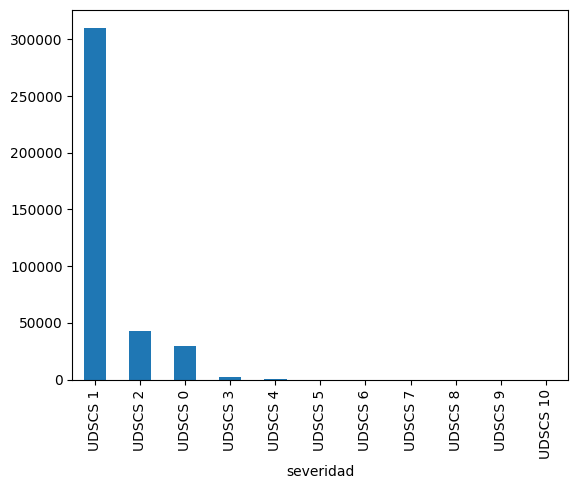

In [4]:
df['severidad'].value_counts().plot(kind='bar')
print(df['severidad'].value_counts())

# Preprocesamiento y Limpieza
- Realizar una limpieza general del dataset, eliminando o corrigiendo datos 
inconsistentes o irrelevantes. 
- Realizar el split del dataset (ej: train y test).  
- Identificar y tratar los valores faltantes en el dataset.
- Detectar y manejar los outliers utilizando técnicas estadísticas o visuales 
apropiadas. 
- Escalar y / o normalizar los features.

In [5]:
# Primer paso, limpieza de columnas que aportan info redundante o no relevante
cols_to_drop = [
    "id", # No sirve el identificador unico
    "active_year", #No considero relevante
    "year", # Redundante con date_start
    "conflict_name", # No considero relevante
    "relid", # Legacy
    "code_status", # Siempre es clear
    "conflict_dset_id", # Legacy
    "conflict_new_id", # Mantener solo conflict_name
    "dyad_name", # Redundante con gwnoa y gwnob
    "dyad_dset_id", # Legacy
    "dyad_new_id", # Mantener solo dyad_name
    "side_a_dset_id", # Legacy
    "side_a_new_id", # Usar solo gwnoa
    "side_b_dset_id", # Legacy
    "side_b_new_id", # Usar solo gwnob
    "source_original", # No considero patronizable
    "source_article", # No considero patronizable
    "source_office", # No considero patronizable
    "source_date", #No considero relevante
    "source_headline", #No considero patronizable
    "where_description", #No considero patronizable
    "latitude", #Posicionar con Country, region y where_coordinates
    "longitude", #Posicionar con Country, region y where_coordinates
    "adm_1", #Posicionar con Country, region y where_coordinates
    "adm_2", #Posicionar con Country, region y where_coordinates
    "geom_wkt", #Posicionar con Country, region y where_coordinates
    "priogrid_gid", #Posicionar con Country, region y where_coordinates
    "country_id", # Usar solo country
    "deaths_a", #Leakage
    "deaths_b", #Leakage
    "deaths_civilians", #Leakage
    "deaths_unknown", #Leakage
    "best", #Leakage
    "high", #Leakage
    "low", #Leakage
]

small_df = df.drop(columns=cols_to_drop)

#Converison a datetime de la columna date_start
small_df['date_start'] = pd.to_datetime(small_df['date_start'])
#Converison a datetime de la columna date_end
small_df['date_end'] = pd.to_datetime(small_df['date_end'])
#Asignamos los -1 de number_of_sources a 1, ya que al menos una fuente siempre hay
small_df['number_of_sources'] = small_df['number_of_sources'].replace(-1, 1)
#Elminamos duplicados
small_df = small_df.drop_duplicates()
small_df.head()

,type_of_violence,side_a,side_b,number_of_sources,where_prec,where_coordinates,country,region,event_clarity,date_prec,date_start,date_end,gwnoa,gwnob,severidad
0,1,Government of Iraq,IS,3,1,Kabul city,Afghanistan,Asia,1,1,2017-07-31,2017-07-31,645,NaN,UDSCS 1
1,1,Government of Iraq,IS,15,1,Kabul international airport,Afghanistan,Asia,1,1,2021-08-26,2021-08-26,645,NaN,UDSCS 3
2,1,Government of Iraq,IS,5,1,Jalalabad town,Afghanistan,Asia,1,1,2021-08-28,2021-08-28,645,NaN,UDSCS 1
3,1,Government of Iraq,IS,8,1,Kabul city,Afghanistan,Asia,1,1,2021-08-29,2021-08-29,645,NaN,UDSCS 2
4,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,1,4,Nangarhar province,Afghanistan,Asia,1,3,1989-01-07,1989-01-13,700,NaN,UDSCS 1


In [6]:
# Split por periodo de tiempo para evitar leakage
date_start_Q1 = small_df["date_start"].dt.year.quantile(0.25)
date_start_Q2 = small_df["date_start"].dt.year.quantile(0.5)
date_start_Q3 = small_df["date_start"].dt.year.quantile(0.75)
print(f"Q1 = {date_start_Q1} | Q2 = {date_start_Q2} | Q3 = {date_start_Q3}")
y1, y2 = small_df["date_start"].dt.year.min(), date_start_Q3  # Esto seria como hacer un split 75/25   
y3, y4 = date_start_Q3+1, small_df["date_start"].dt.year.max()

train = small_df[small_df['date_start'].dt.year.between(y1, y2,inclusive='both')].copy()
test = small_df[small_df['date_start'].dt.year.between(y3, y4,inclusive='both')].copy()
print(f"Periodo train: {y1} - {y2:.0f} | Periodo test: {y3:.0f} - {y4}")
print(f"Tamano train: {train.shape[0]} | Tamano test: {test.shape[0]} | Relacion {((train.shape[0]*100) / small_df.shape[0]):.2f} %")

Q1 = 2007.0 | Q2 = 2014.0 | Q3 = 2020.0
Periodo train: 1989 - 2020 | Periodo test: 2021 - 2024
Tamano train: 282075 | Tamano test: 88157 | Relacion 76.19 %


In [7]:
# Tratamiendo de outliers
def analizar_outliers(df, columnas):
    """
    Da la cantidad de outliers usando el IQR y genera un boxplot.
    
    Params:
    df (dataframe): El DataFrame que contiene los datos.
    columnas (list): Lista con los nombres de las columnas a analizar.
    """
    resultados = {}
    
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
        cantidad_outliers = len(outliers)
        resultados[col] = cantidad_outliers
        print(f"Columna '{col}': {cantidad_outliers} outliers detectados.")
        
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(data=df[columnas], palette="Set2")
    
    plt.title("Box Plot de las columnas seleccionadas", fontsize=14)
    plt.ylabel("Valores", fontsize=12)
    plt.xlabel("Columnas", fontsize=12)
    plt.xticks(rotation=45) # Rotar las etiquetas si son muy largas
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Mostrar el gráfico
    plt.tight_layout()
    plt.show()

    return resultados

Columna 'number_of_sources': 53897 outliers detectados.


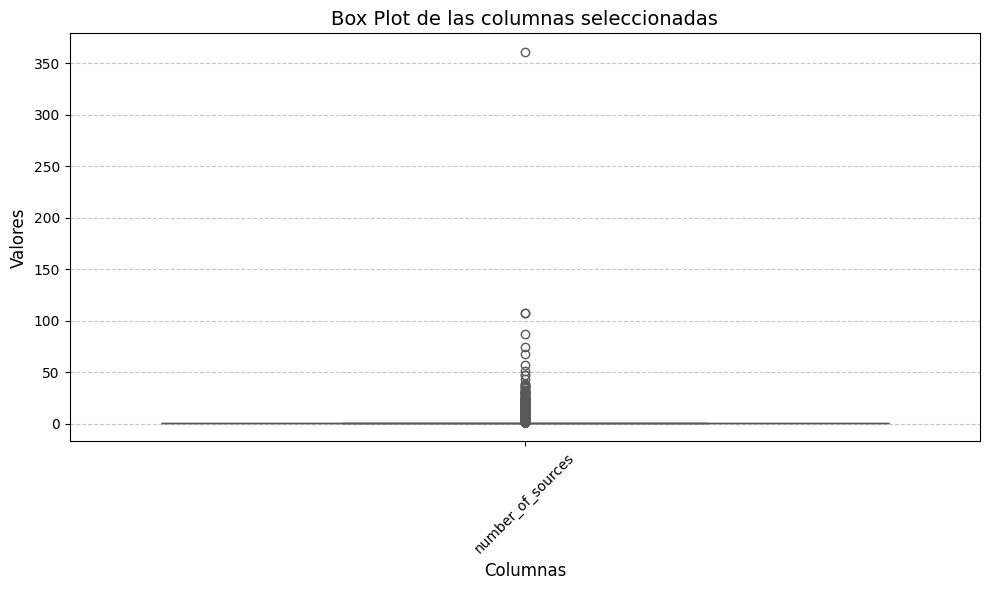

In [8]:
# Aca habria que armar lista con las feautrs numericas, en mi caso por como lo trabaje
# solo tendria esta, pero se hace de la misma forma
numeric_feats = ['number_of_sources']
analizar_outliers(train,numeric_feats)
# En este caso me parece que lo mejor seria hacerle una transformacion logartimica
train['number_of_sources'] = np.log1p(train['number_of_sources']) 


In [9]:
#Tratamieno de faltantes
def analizar_faltantes(df):
    """
    Calcula la cantidad y proporción de valores faltantes
    
    Params:
    df (dataframe)
    """
    columnas = df.columns.tolist()        
    cantidad_faltantes = df[columnas].isnull().sum()
    proporcion_faltantes = df[columnas].isnull().mean() * 100  
    resumen = pd.DataFrame({
        'cant': cantidad_faltantes,
        'prop': proporcion_faltantes
    })
    
    resumen = resumen[resumen['cant'] > 0]
    resumen = resumen.sort_values(by='prop', ascending=False)
    print("--- Resumen de Datos Faltantes ---")
    print(resumen)
    print("-" * 34)

    plt.figure(figsize=(10, 6))    
    ax = sns.barplot(
        x=resumen.index, 
        y='prop', 
        data=resumen, 
    )
    
    plt.title("Datos Faltantes por Columna", fontsize=14)
    plt.ylabel("Porcentaje de Faltantes (%)", fontsize=12)
    plt.xlabel("Columnas", fontsize=12)
    plt.xticks(rotation=45, ha="right") # Rotación para que los nombres no se superpongan
    plt.ylim(0, 100) # Fijar el eje Y de 0 a 100 para tener contexto real del porcentaje
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

    return resumen

--- Resumen de Datos Faltantes ---
         cant       prop
gwnob  280676  99.504033
gwnoa   62457  22.141984
----------------------------------


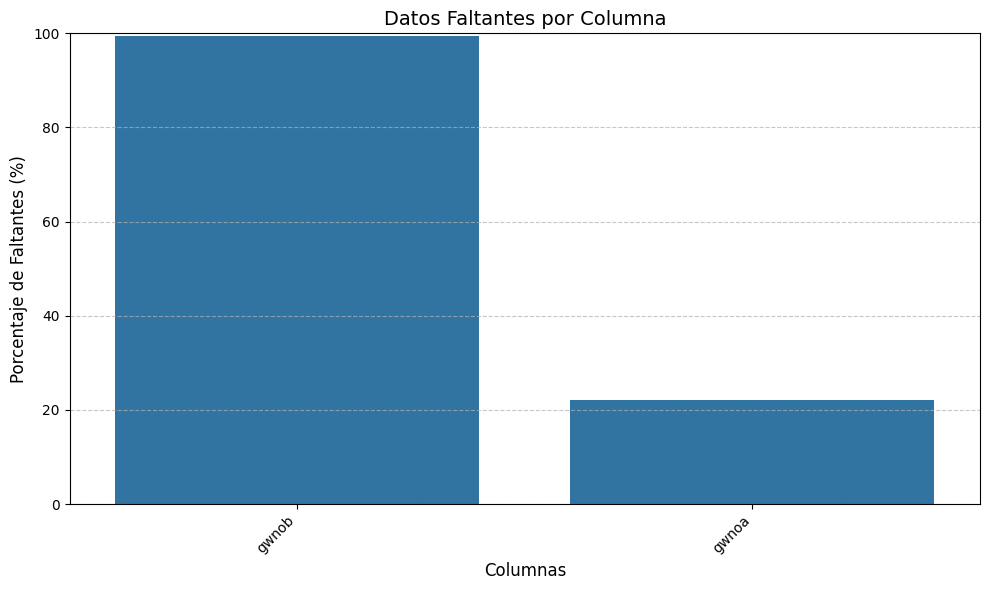

,cant,prop
gwnob,280676,99.504033
gwnoa,62457,22.141984


In [10]:
analizar_faltantes(train)

In [11]:
#En mi caso voy solamente a rellenar con -1 gwnoab y gwnob 
train['gwnoa'] = train['gwnoa'].fillna(-1)
train['gwnob'] = train['gwnob'].fillna(-1)

In [12]:
#Escalado
# En mi caso, solo me quedo una; number_of_sources, le hago estandarizacion
scaler_std = StandardScaler()
# fit_transform calcula la media/desv y aplica la fórmula
train['number_of_sources'] = scaler_std.fit_transform(train[['number_of_sources']])

In [13]:
train.head()

,type_of_violence,side_a,side_b,number_of_sources,where_prec,where_coordinates,country,region,event_clarity,date_prec,date_start,date_end,gwnoa,gwnob,severidad
0,1,Government of Iraq,IS,2.522885,1,Kabul city,Afghanistan,Asia,1,1,2017-07-31,2017-07-31,645,-1.0,UDSCS 1
4,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,4,Nangarhar province,Afghanistan,Asia,1,3,1989-01-07,1989-01-13,700,-1.0,UDSCS 1
5,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,4,Kunduz province,Afghanistan,Asia,2,2,1989-01-15,1989-01-18,700,-1.0,UDSCS 1
6,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,1,Salang pass,Afghanistan,Asia,1,2,1989-01-23,1989-01-24,700,-1.0,UDSCS 3
7,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,1,Kabul city,Afghanistan,Asia,1,3,1989-01-30,1989-02-05,700,-1.0,UDSCS 1


# Feature Engineering
- Crear nuevos features en caso de ser necesario. Justificar. 
- Aplicar técnicas de conversión de variables: codificación, discretización. 
- Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación). 
- Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

In [14]:
#Features propuestos
# side_a_es_estado -> apartir de si gwnoa es -1
# side_b_es_estado -> apartir de si gwnob es -1
# mes -> a partir de date_start
# duracion -> a partir de date_end - date_start 
# certeza_source -> 0 si es anterior a 2013, por eso de los cambios sufridos a partri de esa fecha

train['side_a_es_estado'] = (train['gwnoa'] != -1).astype(int)
train['side_b_es_estado'] = (train['gwnob'] != -1).astype(int)

# No quiero mas a gwnoa y gwnob asi q los dropeo
train.drop(columns=['gwnoa','gwnob'],inplace=True)

train['mes'] = train['date_start'].dt.month

train['duracion_dias'] = (train['date_end'] - train['date_start']).dt.days + 1

train['certeza_source'] = (train['date_start'].dt.year >= 2013).astype(int)

# No quiero mas date_start ni end
train.drop(columns=['date_start','date_end'],inplace=True)

train.head()

,type_of_violence,side_a,side_b,number_of_sources,where_prec,where_coordinates,country,region,event_clarity,date_prec,severidad,side_a_es_estado,side_b_es_estado,mes,duracion_dias,certeza_source
0,1,Government of Iraq,IS,2.522885,1,Kabul city,Afghanistan,Asia,1,1,UDSCS 1,1,0,7,1,1
4,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,4,Nangarhar province,Afghanistan,Asia,1,3,UDSCS 1,1,0,1,7,0
5,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,4,Kunduz province,Afghanistan,Asia,2,2,UDSCS 1,1,0,1,4,0
6,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,1,Salang pass,Afghanistan,Asia,1,2,UDSCS 3,1,0,1,2,0
7,1,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-0.426221,1,Kabul city,Afghanistan,Asia,1,3,UDSCS 1,1,0,1,7,0


Columna 'duracion_dias': 40419 outliers detectados.


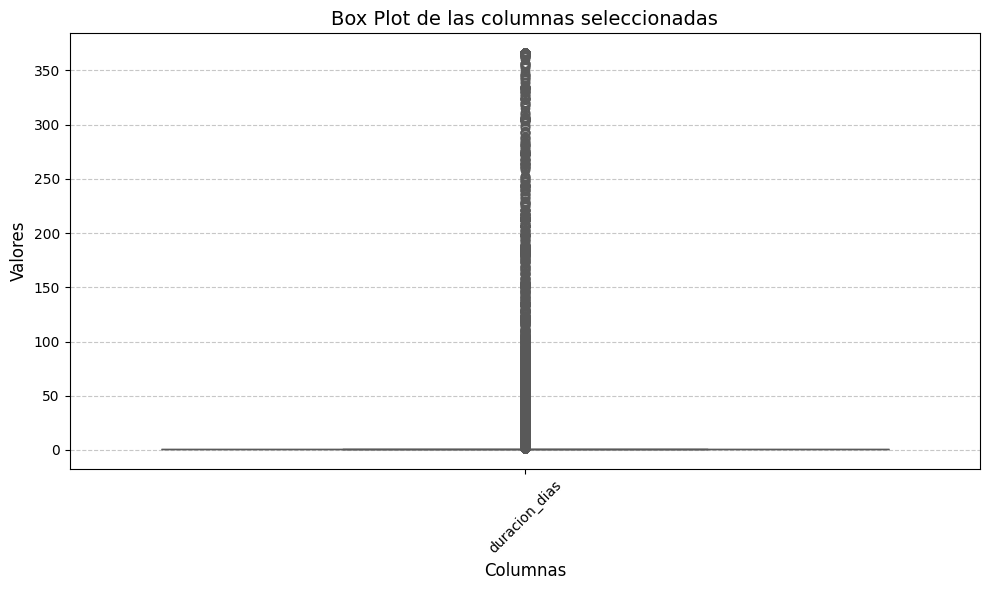

{'duracion_dias': 40419}

In [15]:
#Reviso los outliers de duracion_dias por las dudas
analizar_outliers(train,['duracion_dias'])

In [16]:
#Le aplicamos logaritmo y estandarizado
train['duracion_dias'] = np.log1p(train['duracion_dias']) 
scaler_std = StandardScaler()
train['duracion_dias'] = scaler_std.fit_transform(train[['duracion_dias']])

In [17]:
#Codificiacion
#Propongo la siguiente codificiacion:
#type_of_violence -> One Hot, solo son 3
#side_a, side_b, where_coordinates, country-> Son una banda, frenquency encoding
#region -> One hot, solo son 5
#where prec, event_clarity, date_prec ->  Ya tienen un ordinal encoding, faltaria estandarizarlas
#severidad -> Label enconding, es la target
#mes -> Cyclic encoding, es ciclica
#side_a_es_estado, side_b_es_estado, certeza_source -> Nada, son binarias

#One hot
cols_one_hot = ['type_of_violence', 'region']
train = pd.get_dummies(train, columns=cols_one_hot, drop_first=True, dtype=int)

#Frequency
cols_freq = ['side_a', 'side_b', 'where_coordinates', 'country']
for col in cols_freq:
    frecuencias = train[col].value_counts(normalize=True)
    train[col] = train[col].map(frecuencias)

#Estandarizacion
cols_std = ['where_prec', 'event_clarity', 'date_prec']
scaler = StandardScaler()
train[cols_std] = scaler.fit_transform(train[cols_std])

#Label
le = LabelEncoder()
train['severidad'] = le.fit_transform(train['severidad'])

#Cyclic
train['mes_sin'] = np.sin(2 * np.pi * train['mes'] / 12)
train['mes_cos'] = np.cos(2 * np.pi * train['mes'] / 12)
train.drop(columns=['mes'], inplace=True)

train.head()

,side_a,side_b,number_of_sources,where_prec,where_coordinates,country,event_clarity,date_prec,severidad,side_a_es_estado,...,duracion_dias,certeza_source,type_of_violence_2,type_of_violence_3,region_Americas,region_Asia,region_Europe,region_Middle East,mes_sin,mes_cos
0,0.020842,0.062696,2.522885,-0.851239,0.003574,0.130004,-0.279264,-0.338070,1,1,...,-0.279152,1,0,0,0,1,0,0,-0.5,-0.866025
4,0.123779,0.000340,-0.426221,1.561807,0.001358,0.130004,-0.279264,2.651823,1,1,...,2.119244,0,0,0,0,1,0,0,0.5,0.866025
5,0.123779,0.000340,-0.426221,1.561807,0.000971,0.130004,3.580847,1.156877,1,1,...,1.306102,0,0,0,0,1,0,0,0.5,0.866025
6,0.123779,0.000340,-0.426221,-0.851239,0.000025,0.130004,-0.279264,1.156877,3,1,...,0.422334,0,0,0,0,1,0,0,0.5,0.866025
7,0.123779,0.000340,-0.426221,-0.851239,0.003574,0.130004,-0.279264,2.651823,1,1,...,2.119244,0,0,0,0,1,0,0,0.5,0.866025


<Axes: xlabel='severidad'>

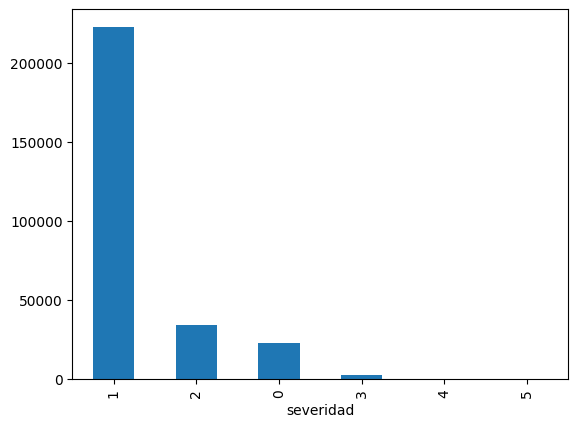

In [18]:
#Analisis de balance de clase
train['severidad'].value_counts().plot(kind='bar')

In [19]:
# smote = SMOTE(random_state=42)
# X_train_sm, y_train_sm = smote.fit_resample(train.drop(columns='severidad'), train['severidad'])
# train_balanceado = pd.concat([X_train_sm, y_train_sm], axis=1)
# train_balanceado.value_counts().plot(kind='bar')                                          

# Reduccion de dimensionalidad 
- Evaluar relaciones entre variables y realizar una selección de features con los 
mecanismos vistos en clase (ej: filtros). 
- Implementar técnicas de extracción de features (ej: PCA). Evaluar ventajas y 
desventajas de la reducción. 

In [21]:
print(train.columns)

Index(['side_a', 'side_b', 'number_of_sources', 'where_prec',
       'where_coordinates', 'country', 'event_clarity', 'date_prec',
       'severidad', 'side_a_es_estado', 'side_b_es_estado', 'duracion_dias',
       'certeza_source', 'type_of_violence_2', 'type_of_violence_3',
       'region_Americas', 'region_Asia', 'region_Europe', 'region_Middle East',
       'mes_sin', 'mes_cos'],
      dtype='object')


In [ ]:
#Separor las features
num_feats = ['number_of_sources','duracion_dias']
cat_feats = train.drop(columns=num_feats).columns.to_list()
cat_feats.remove('severidad')

In [36]:
#Correlacion de pearson
corr_con_target = (train[num_feats]
                    .corrwith(train['severidad'], method='pearson')
                    .sort_values(ascending=False))


print ("Correlación con la variable target (Pearson):")
print(corr_con_target)

#Correlacion de spearman
sp_con_target = (train[num_feats]
                    .corrwith(train['severidad'], method='spearman')
                    .sort_values(ascending=False))

print ("Correlación con la variable target (Spearman):")
print(sp_con_target)

#Correlacion de Kendall
kdl_con_target = (train[num_feats]
                    .corrwith(train['severidad'], method='kendall')
                    .sort_values(ascending=False))

print ("Correlación con la variable target (Kendall):")
print(kdl_con_target)


Correlación con la variable target (Pearson):
number_of_sources    0.137877
duracion_dias        0.127147
dtype: float64
Correlación con la variable target (Spearman):
duracion_dias        0.118529
number_of_sources    0.104766
dtype: float64
Correlación con la variable target (Kendall):
duracion_dias        0.113038
number_of_sources    0.100409
dtype: float64


In [ ]:
#Anova
selector_anova = SelectKBest(score_func=f_classif, k='all') # se puede usar f_regression cuando la v.a. target es numérica
X_train_num_best = selector_anova.fit_transform(train[num_feats], train['severidad'])

selected_indices = selector_anova.get_support() # Esta función me devuelve los features seleccionados
selected_features = train[num_feats].columns[selected_indices]
p_values = selector_anova.pvalues_[selected_indices]
scores = selector_anova.scores_[selected_indices]

print(f"Numéricas antes de filtrar: {train[num_feats].columns.tolist()}")
print("\nCaracterísticas seleccionadas (ANOVA):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

print("\nP-valores de todas las características:")
for feature, p_valor in zip(train[num_feats].columns, p_values):
    print(f"{feature}: {p_valor}")

Numéricas antes de filtrar: ['number_of_sources', 'duracion_dias']

Características seleccionadas (ANOVA):
number_of_sources: 1281.2119
duracion_dias: 3958.0930

P-valores de todas las características:
number_of_sources: 0.0
duracion_dias: 0.0


In [45]:
#Chi cuadrado
selector_chi2 = SelectKBest(score_func=chi2, k=15)
X_train_cat_best = selector_chi2.fit_transform(train[cat_feats].drop(columns=['mes_sin','mes_cos']), train['severidad'])

chi2_selected_indices = selector_chi2.get_support()
chi2_selected_features = train[cat_feats].columns[chi2_selected_indices]

scores = selector_chi2.scores_[chi2_selected_indices]
p_values = selector_chi2.pvalues_[chi2_selected_indices]

print(f"Categóricas antes de filtrar: {train[cat_feats].columns.tolist()}")

print("\nScores de los feature seleccionadas (Chi2):")
for feature, score in zip(chi2_selected_features, scores):
    print(f"{feature}: {score:.4f}")

print("\nP-valores de los features analizados:")
for feature, p_valor in zip(chi2_selected_features, p_values):
    print(f"{feature}: {p_valor}")

ValueError: Input X must be non-negative.

In [40]:
# Informacion Mutua
selector_mi = SelectKBest(score_func=mutual_info_classif, k=20) # también se puede usar mutual_info_regression para problemas de ese tipo
X_train_best = selector_mi.fit_transform(train.drop(columns=['severidad']), train['severidad']) # todos los tipos de features
selected_indices = selector_mi.get_support()
selected_features = train.drop(columns=['severidad']).columns[selected_indices]
scores = selector_mi.scores_[selected_indices]

print("\nCaracterísticas seleccionadas (Inf. mutua):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")


Características seleccionadas (Inf. mutua):
side_a: 0.0777
side_b: 0.0682
number_of_sources: 0.0233
where_prec: 0.0108
where_coordinates: 0.0249
country: 0.0693
event_clarity: 0.0311
date_prec: 0.0335
side_a_es_estado: 0.0402
side_b_es_estado: 0.0005
duracion_dias: 0.0338
certeza_source: 0.0323
type_of_violence_2: 0.0019
type_of_violence_3: 0.0058
region_Americas: 0.0040
region_Asia: 0.0111
region_Europe: 0.0014
region_Middle East: 0.0215
mes_sin: 0.0070
mes_cos: 0.0058


In [42]:
pca = PCA(n_components=10) # PCA con 2 componentes principales
pca.fit(train.drop(columns=['severidad']))                # calcula los autovalores y autovectores (por defecto, centra los datos, pero no los escala!)

print("\nVarianza de cada componente:", pca.explained_variance_)        # Autovalores
print("\nVarianza explicada (%):", pca.explained_variance_ratio_ * 100) # varianza explicada
print("\nComponentes principales:\n", pca.components_)                  # Autovectores


Varianza de cada componente: [2.46509724 1.15100956 0.84903311 0.55784455 0.50198053 0.49525517
 0.3817757  0.2719868  0.19324645 0.13984896]

Varianza explicada (%): [33.83867627 15.80004197 11.65477617  7.65759699  6.89074501  6.79842523
  5.24067941  3.73359441  2.65271644  1.91972299]

Componentes principales:
 [[-1.05089267e-02 -5.97994707e-03 -8.70952436e-02  2.15942823e-01
  -1.09704127e-04 -1.40906814e-02  4.81867786e-01  6.03706240e-01
  -1.39774673e-02  4.36213840e-04  5.84238061e-01 -1.89112901e-02
   1.11958371e-02  1.54943101e-02  1.09606291e-03  2.82126705e-02
  -7.62146099e-03 -6.87825645e-02  2.42868212e-02  1.87538994e-02]
 [ 1.28440286e-02  1.04298937e-02  7.25445880e-01 -6.12889665e-01
   2.21994712e-04  1.73820633e-02 -9.66923472e-03  1.70890852e-01
  -1.27095406e-02 -1.72138756e-03  1.84565859e-01  1.00455358e-01
   2.06758977e-02 -3.74302074e-03 -1.68162833e-02 -1.25343676e-01
   2.53438756e-02  8.09691281e-02  1.29642511e-02  9.96883390e-03]
 [ 1.44031623e-02  1